# Thumbnail Age Analysis Pipeline

유튜브 채널의 썸네일 이미지를 분석하여, **시각적 특징만으로 타겟 연령대를 구분할 수 있는지** 검증하는 파이프라인입니다.

## 데이터 개요

| 파일 | 설명 |
|---|---|
| `YT_dataset_v1.csv` | 영상별 메타데이터 + 썸네일 로컬 경로 |
| `YT_channelsList_v1.csv` | 채널별 타겟 연령대 레이블 (`18-24` ~ `65+`) |

## 파이프라인 단계

```
Step 1: prepare   → Shorts 필터링, 데이터 정제
Step 2: extract   → 비전 모델로 썸네일 임베딩 추출
Step 3: evaluate  → 모델 간 클러스터링 성능 비교
Step 4: visualize → UMAP / t-SNE 시각화 + 최근접 이웃 분석
```

---
## 라이브러리 & 전역 설정

파이프라인 전체에서 사용하는 패키지를 임포트하고 경로·하이퍼파라미터 상수를 정의합니다.

In [1]:
from __future__ import annotations

import csv
import json
import re
import sys
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

# ── 경로 설정 ──────────────────────────────────────────────────────────────
YOUTUBE_CSV   = Path("YT_dataset_v1.csv")
CHANNELS_CSV  = Path("YT_channelsList_v1.csv")
OUTPUT_DIR    = Path("artifacts")
EMBEDDINGS_DIR = OUTPUT_DIR / "embeddings"
EVAL_DIR      = OUTPUT_DIR / "evaluation"
VIZ_DIR       = OUTPUT_DIR / "visualizations"

# ── Shorts 판별 파라미터 ───────────────────────────────────────────────────
SHORT_DURATION_SEC      = 180          # 이 초 이하면 Shorts 후보
SHORT_KEYWORD_REGEX     = r"(?i)(?:^|\s|#)(shorts?|쇼츠)\b"

# ── 모델 설정 ─────────────────────────────────────────────────────────────
MODEL_ALIASES = {
    "dinov2-base":  "facebook/dinov2-base",
    "siglip2-base": "google/siglip2-base-patch16-224",
}
MODELS_TO_RUN = "dinov2-base,siglip2-base"   # 쉼표로 여러 모델 지정 가능
BATCH_SIZE    = 32
DEVICE        = "auto"   # "auto" | "cpu" | "cuda"

# ── 차원 축소·평가 파라미터 ────────────────────────────────────────────────
UMAP_NEIGHBORS  = 20
UMAP_MIN_DIST   = 0.1
TSNE_PERPLEXITIES = [5, 15, 30]
NN_TOP_K        = 5
SEEDS           = [42, 43, 44]

print("설정 완료")
print(f"  youtube_csv  : {YOUTUBE_CSV}")
print(f"  channels_csv : {CHANNELS_CSV}")
print(f"  output_dir   : {OUTPUT_DIR}")

설정 완료
  youtube_csv  : YT_dataset_v1.csv
  channels_csv : YT_channelsList_v1.csv
  output_dir   : artifacts


---
## 공통 유틸리티 함수

파이프라인 전 단계에서 재사용되는 파일 I/O, 파싱, 경로 처리 함수입니다.

In [2]:
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def parse_iso_duration_to_seconds(duration: str) -> Optional[int]:
    """PT#H#M#S 형식의 ISO 8601 duration → 초 단위 정수."""
    m = re.fullmatch(r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?", duration or "")
    if not m:
        return None
    hours, minutes, seconds = m.groups()
    return int(hours or 0) * 3600 + int(minutes or 0) * 60 + int(seconds or 0)


def truthy(value: str) -> Optional[bool]:
    """문자열 → bool 변환. 인식 불가 값은 None 반환."""
    if value is None:
        return None
    v = value.strip().lower()
    if v in {"1", "true", "t", "yes", "y"}:
        return True
    if v in {"0", "false", "f", "no", "n"}:
        return False
    return None


def read_csv_rows(path: Path, encoding: str = "utf-8-sig") -> List[Dict[str, str]]:
    with path.open("r", encoding=encoding, newline="") as f:
        return list(csv.DictReader(f))


def write_csv_rows(
    path: Path,
    fieldnames: Sequence[str],
    rows: Iterable[Dict],
) -> None:
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)


def build_channel_age_map(channels_csv: Path) -> Dict[str, str]:
    """channels CSV → {channel_id: target_age} 딕셔너리."""
    rows = read_csv_rows(channels_csv)
    return {
        (r.get("channel_id") or "").strip(): (r.get("target_age") or "").strip()
        for r in rows
        if (r.get("channel_id") or "").strip()
    }


print("유틸리티 함수 정의 완료")

유틸리티 함수 정의 완료


---
## Step 1: 데이터 준비 (`prepare`)

### 목적
원본 영상 데이터에서 **Shorts 영상을 필터링**하고, 타겟 연령대 레이블을 병합하여 실험용 데이터셋을 만듭니다.

### Shorts 판별 로직 (2단계)

| 기준 | 내용 |
|---|---|
| `duration` | 영상 길이 ≤ `SHORT_DURATION_SEC` (기본 180초) |
| `keyword` | 제목·설명·태그에 `Shorts` / `쇼츠` 포함 |

둘 중 하나라도 해당하면 `is_short_auto = True`로 표시하고 검토 후보로 분류합니다.

### 수동 검토 플로우

```
is_short_auto  →  manual_review_template.csv 작성  →  is_short_manual  →  is_short_final
```

### 출력 파일

| 파일 | 용도 |
|---|---|
| `dataset_with_flags.csv` | 전체 데이터 + 모든 플래그 |
| `manual_review_candidates.csv` | Shorts 의심 영상 목록 |
| `manual_review_template.csv` | 수동 레이블 입력 템플릿 |
| `dataset_nonshort_auto.csv` | 자동 기준 비-Shorts |
| `dataset_nonshort_final.csv` | 최종 확정 비-Shorts (임베딩 추출 대상) |
| `prepare_summary.json` | 통계 요약 |

In [3]:
def _short_reason(
    duration_sec: Optional[int],
    text: str,
    short_duration_sec: int,
    keyword_re: re.Pattern,
) -> Tuple[bool, str]:
    """Shorts 판별 이유를 (is_short, reason_string) 형태로 반환."""
    reasons: List[str] = []
    if duration_sec is not None and duration_sec <= short_duration_sec:
        reasons.append("duration")
    if keyword_re.search(text):
        reasons.append("keyword")
    return (len(reasons) > 0, "|".join(reasons))


def prepare_dataset(
    youtube_csv: Path = YOUTUBE_CSV,
    channels_csv: Path = CHANNELS_CSV,
    output_dir: Path = OUTPUT_DIR,
    short_duration_sec: int = SHORT_DURATION_SEC,
    keyword_regex: str = SHORT_KEYWORD_REGEX,
    manual_labels_csv: Optional[Path] = None,
) -> None:
    ensure_dir(output_dir)

    channel_age = build_channel_age_map(channels_csv)
    keyword_re  = re.compile(keyword_regex)
    video_rows  = read_csv_rows(youtube_csv)

    merged_rows: List[Dict] = []
    skipped_no_path = 0
    for row in video_rows:
        thumbnail_path = (row.get("thumbnail_path") or "").strip()
        if not thumbnail_path:
            skipped_no_path += 1
            continue
        # 썸네일 존재 여부는 extract 단계에서 처리 — 여기서는 경로가 있으면 포함

        duration     = (row.get("duration") or "").strip()
        duration_sec = parse_iso_duration_to_seconds(duration)
        text_blob    = " ".join([
            row.get("title", "") or "",
            row.get("description", "") or "",
            row.get("tags", "") or "",
        ])
        is_short_auto, short_reason = _short_reason(
            duration_sec=duration_sec,
            text=text_blob,
            short_duration_sec=short_duration_sec,
            keyword_re=keyword_re,
        )
        video_id   = (row.get("video_id") or "").strip()
        channel_id = (row.get("channel_id") or "").strip()

        merged_rows.append({
            "channel_name":  (row.get("channel_name") or "").strip(),
            "channel_id":    channel_id,
            "video_id":      video_id,
            "target_age":    channel_age.get(channel_id, ""),
            "title":         (row.get("title") or "").strip(),
            "published_at":  (row.get("published_at") or "").strip(),
            "duration":      duration,
            "duration_sec":  duration_sec if duration_sec is not None else "",
            "thumbnail_path": thumbnail_path,
            "thumbnail_url": (row.get("thumbnail_url") or "").strip(),
            "youtube_watch_url": f"https://www.youtube.com/watch?v={video_id}" if video_id else "",
            "is_short_auto":   is_short_auto,
            "short_reason":    short_reason,
            "is_short_manual": "",
            "short_check_note": "",
            "is_short_final":  "",
        })

    # 수동 레이블 병합 (선택적)
    manual_labels: Dict[str, Tuple[bool, str]] = {}
    if manual_labels_csv and manual_labels_csv.exists():
        for r in read_csv_rows(manual_labels_csv, encoding="utf-8"):
            vid    = (r.get("video_id") or "").strip()
            parsed = truthy(r.get("is_short_manual", ""))
            if vid and parsed is not None:
                manual_labels[vid] = (parsed, (r.get("short_check_note") or "").strip())

    for row in merged_rows:
        vid = str(row["video_id"])
        if vid in manual_labels:
            row["is_short_manual"]  = manual_labels[vid][0]
            row["short_check_note"] = manual_labels[vid][1]
            row["is_short_final"]   = manual_labels[vid][0]
        else:
            row["is_short_final"] = bool(row["is_short_auto"])

    fieldnames = [
        "channel_name", "channel_id", "video_id", "target_age",
        "title", "published_at", "duration", "duration_sec",
        "thumbnail_path", "thumbnail_url", "youtube_watch_url",
        "is_short_auto", "short_reason", "is_short_manual",
        "short_check_note", "is_short_final",
    ]

    write_csv_rows(output_dir / "dataset_with_flags.csv", fieldnames, merged_rows)

    candidates = [r for r in merged_rows if bool(r["is_short_auto"])]
    write_csv_rows(output_dir / "manual_review_candidates.csv", fieldnames, candidates)

    review_fields = [
        "video_id", "channel_name", "title", "duration", "duration_sec",
        "short_reason", "youtube_watch_url", "thumbnail_path",
        "is_short_manual", "short_check_note",
    ]
    template_rows = [
        {k: r[k] if k not in ("is_short_manual", "short_check_note") else ""
         for k in review_fields}
        for r in candidates
    ]
    write_csv_rows(output_dir / "manual_review_template.csv", review_fields, template_rows)

    non_short_auto  = [r for r in merged_rows if not bool(r["is_short_auto"])]
    non_short_final = [r for r in merged_rows if not bool(r["is_short_final"])]
    write_csv_rows(output_dir / "dataset_nonshort_auto.csv",   fieldnames, non_short_auto)
    write_csv_rows(output_dir / "dataset_nonshort_final.csv",  fieldnames, non_short_final)

    summary = {
        "total_rows":           len(merged_rows),
        "short_auto_count":     len(candidates),
        "nonshort_auto_count":  len(non_short_auto),
        "nonshort_final_count": len(non_short_final),
        "manual_label_count":   len(manual_labels),
        "age_distribution_all":          dict(Counter(str(r["target_age"]) for r in merged_rows)),
        "age_distribution_nonshort_final": dict(Counter(str(r["target_age"]) for r in non_short_final)),
        "params": {"short_duration_sec": short_duration_sec, "keyword_regex": keyword_regex},
    }
    with (output_dir / "prepare_summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print(f"total        : {len(merged_rows)}  (썸네일 경로 없음으로 건너뜀: {skipped_no_path})")
    print(f"short_auto   : {len(candidates)}")
    print(f"nonshort_auto: {len(non_short_auto)}")
    print(f"nonshort_final (임베딩 대상): {len(non_short_final)}")
    print(f"manual_labels: {len(manual_labels)}")
    print(f"출력 디렉터리: {output_dir}")


print("prepare 함수 정의 완료")

prepare 함수 정의 완료


In [4]:
# ── Step 1 실행 ────────────────────────────────────────────────────────────
# 수동 검토 파일이 있으면 MANUAL_LABELS_CSV 경로를 지정하세요.
MANUAL_LABELS_CSV = None   # 예: Path("manual_review_template_filled.csv")

prepare_dataset(
    youtube_csv=YOUTUBE_CSV,
    channels_csv=CHANNELS_CSV,
    output_dir=OUTPUT_DIR,
    short_duration_sec=SHORT_DURATION_SEC,
    keyword_regex=SHORT_KEYWORD_REGEX,
    manual_labels_csv=MANUAL_LABELS_CSV,
)

total        : 270  (썸네일 경로 없음으로 건너뜀: 0)
short_auto   : 111
nonshort_auto: 159
nonshort_final (임베딩 대상): 159
manual_labels: 0
출력 디렉터리: artifacts


---
## Step 1.5: 썸네일 다운로드

`YT_dataset_v1.csv`의 `thumbnail_url` 컬럼에서 이미지를 받아 `thumbnail_path`에 저장합니다.  
이미 다운로드된 파일은 건너뛰므로 **중단 후 재실행해도 안전**합니다.

> Step 2(extract)를 실행하기 전에 반드시 실행하세요.

In [5]:
import urllib.request
import time

def download_thumbnails(
    dataset_csv: Path = OUTPUT_DIR / "dataset_nonshort_final.csv",
    delay: float = 0.3,
) -> None:
    """
    CSV의 thumbnail_url을 받아 thumbnail_path 위치에 저장.
    이미 존재하는 파일은 건너뜀.
    """
    rows = read_csv_rows(dataset_csv, encoding="utf-8")
    if not rows:
        print("CSV가 비어 있습니다. Step 1을 먼저 실행하세요.")
        return

    total    = len(rows)
    skipped  = 0   # 이미 존재
    success  = 0
    failed   = 0

    headers = {"User-Agent": "Mozilla/5.0"}

    for i, row in enumerate(rows, 1):
        url  = (row.get("thumbnail_url") or "").strip()
        path = Path((row.get("thumbnail_path") or "").strip())

        if not url or not str(path):
            skipped += 1
            continue

        if path.exists():
            skipped += 1
            continue

        ensure_dir(path.parent)
        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=10) as resp:
                path.write_bytes(resp.read())
            success += 1
        except Exception as e:
            failed += 1
            print(f"  [실패] {path.name}: {e}")

        if i % 50 == 0:
            print(f"  진행: {i}/{total}  (완료:{success}, 건너뜀:{skipped}, 실패:{failed})")

        time.sleep(delay)

    print(f"\n다운로드 완료")
    print(f"  성공:    {success}")
    print(f"  건너뜀:  {skipped}  (이미 존재하거나 경로 없음)")
    print(f"  실패:    {failed}")


print("download_thumbnails 함수 정의 완료")

download_thumbnails 함수 정의 완료


In [6]:
# ── Step 1.5 실행 ──────────────────────────────────────────────────────────
# delay: 요청 간 대기 시간(초). 너무 빠르면 YouTube에서 차단될 수 있음.
# 전체 dataset(Shorts 포함)을 먼저 받으려면 dataset_with_flags.csv 경로로 변경 가능.

download_thumbnails(
    dataset_csv=OUTPUT_DIR / "dataset_nonshort_final.csv",
    delay=0.3,
)

  [실패] KICNuB7uAyE.jpg: HTTP Error 404: Not Found

다운로드 완료
  성공:    0
  건너뜀:  158  (이미 존재하거나 경로 없음)
  실패:    1


---
## Step 2: 임베딩 추출 (`extract`)

### 목적
HuggingFace 비전 모델로 썸네일 이미지를 **고차원 벡터(임베딩)** 로 변환합니다.  
추출된 임베딩은 Step 3·4에서 연령대 분류 성능 평가와 시각화에 사용됩니다.

### 지원 모델

| alias | HuggingFace ID | 특징 |
|---|---|---|
| `dinov2-base` | `facebook/dinov2-base` | 자기지도 ViT, 이미지 전용 |
| `siglip2-base` | `google/siglip2-base-patch16-224` | 이미지-텍스트 대조 학습 |

> **SigLIP 계열 주의:** 모델 구조상 텍스트 입력도 요구하므로 `"thumbnail"` 더미 텍스트를 자동 삽입합니다.

### 임베딩 추출 우선순위

```
image_embeds  →  pooler_output  →  last_hidden_state[:, 0]  →  tuple[0][:, 0]
```

추출 후 **L2 정규화** 적용 → 이후 내적(dot product)이 코사인 유사도와 동일해집니다.

### 출력 (모델별 서브 디렉터리)

| 파일 | 내용 |
|---|---|
| `embeddings.npy` | `(N, D)` float32 배열 |
| `metadata.csv` | 영상별 메타데이터 |
| `run_info.json` | 실행 파라미터 기록 |

In [7]:
@dataclass
class LoadedModel:
    model_id:  str
    alias:     str
    processor: object
    model:     object
    device:    str


def _resolve_device(requested: str) -> str:
    if requested != "auto":
        return requested
    try:
        import torch
        if torch.cuda.is_available():
            return "cuda"
    except Exception:
        pass
    return "cpu"


def _resolve_model_id(alias_or_id: str) -> Tuple[str, str]:
    alias_or_id = alias_or_id.strip()
    if alias_or_id in MODEL_ALIASES:
        return alias_or_id, MODEL_ALIASES[alias_or_id]
    safe_alias = re.sub(r"[^a-zA-Z0-9._-]+", "_", alias_or_id)
    return safe_alias, alias_or_id


def _load_transformers_model(alias_or_id: str, device: str) -> LoadedModel:
    from transformers import AutoImageProcessor, AutoModel, AutoProcessor

    alias, model_id = _resolve_model_id(alias_or_id)
    model = AutoModel.from_pretrained(model_id)
    try:
        processor = AutoProcessor.from_pretrained(model_id)
    except Exception:
        processor = AutoImageProcessor.from_pretrained(model_id)
    model = model.to(device).eval()
    return LoadedModel(model_id=model_id, alias=alias, processor=processor, model=model, device=device)


def _extract_batch_embeddings(loaded: LoadedModel, pil_images: list):
    import torch
    import torch.nn.functional as F

    def to_device(obj):
        if isinstance(obj, dict):
            return {k: v.to(loaded.device) for k, v in obj.items() if hasattr(v, "to")}
        return obj.to(loaded.device)

    try:
        inputs = to_device(loaded.processor(images=pil_images, return_tensors="pt"))
        with torch.no_grad():
            out = loaded.model(**inputs)
    except Exception as e:
        if "input_ids" not in str(e).lower():
            raise
        # SigLIP 계열: 텍스트 더미 입력 필요
        dummy_text = ["thumbnail"] * len(pil_images)
        inputs = to_device(
            loaded.processor(text=dummy_text, images=pil_images, return_tensors="pt", padding=True)
        )
        with torch.no_grad():
            out = loaded.model(**inputs)

    if hasattr(out, "image_embeds") and out.image_embeds is not None:
        emb = out.image_embeds
    elif hasattr(out, "pooler_output") and out.pooler_output is not None:
        emb = out.pooler_output
    elif hasattr(out, "last_hidden_state") and out.last_hidden_state is not None:
        lhs = out.last_hidden_state
        emb = lhs[:, 0] if lhs.ndim == 3 else lhs
    elif isinstance(out, tuple):
        emb = out[0]
        if emb.ndim == 3:
            emb = emb[:, 0]
    else:
        raise RuntimeError("임베딩 텐서를 모델 출력에서 추출할 수 없습니다.")

    return F.normalize(emb, dim=-1).detach().cpu().numpy()


def extract_embeddings(
    dataset_csv: Path = OUTPUT_DIR / "dataset_nonshort_final.csv",
    output_root: Path = EMBEDDINGS_DIR,
    models: str = MODELS_TO_RUN,
    batch_size: int = BATCH_SIZE,
    device: str = DEVICE,
) -> None:
    import numpy as np
    from PIL import Image

    ensure_dir(output_root)
    rows = read_csv_rows(dataset_csv, encoding="utf-8")
    if not rows:
        raise RuntimeError(
            f"CSV가 비어 있습니다: {dataset_csv}\n"
            "→ Step 1 (prepare) 셀을 다시 실행한 뒤 재시도하세요."
        )

    # 전체 dataset_with_flags.csv 사용 시 Shorts 제외
    # dataset_nonshort_final.csv 사용 시 is_short_final이 False이므로 모두 통과
    filtered = [
        r for r in rows
        if truthy(r.get("is_short_final", "")) is not True
    ]
    if not filtered:
        raise RuntimeError(
            f"필터링 후 남은 행이 없습니다 (전체 {len(rows)}행).\n"
            "→ is_short_final 컬럼 값을 확인하거나 dataset_nonshort_final.csv를 사용하세요."
        )

    device_str  = _resolve_device(device)
    model_specs = [m.strip() for m in models.split(",") if m.strip()]

    print(f"추출 대상: {len(filtered)}행 | 디바이스: {device_str} | 모델: {model_specs}")

    for model_name in model_specs:
        print(f"\n[{model_name}] 모델 로드 중...")
        loaded   = _load_transformers_model(model_name, device=device_str)
        model_dir = output_root / loaded.alias
        ensure_dir(model_dir)

        all_embs, all_meta = [], []
        batch_imgs, batch_meta_buf = [], []

        def flush():
            if not batch_imgs:
                return
            for i, emb in enumerate(_extract_batch_embeddings(loaded, batch_imgs)):
                all_embs.append(emb)
                all_meta.append(batch_meta_buf[i])
            batch_imgs.clear()
            batch_meta_buf.clear()

        missing_thumb = 0
        for row in filtered:
            thumb = Path(row["thumbnail_path"])
            if not thumb.exists():
                missing_thumb += 1
                continue
            try:
                img = Image.open(thumb).convert("RGB")
            except Exception:
                continue
            batch_imgs.append(img)
            batch_meta_buf.append({
                "video_id":       row.get("video_id", ""),
                "channel_id":     row.get("channel_id", ""),
                "channel_name":   row.get("channel_name", ""),
                "target_age":     row.get("target_age", ""),
                "published_at":   row.get("published_at", ""),
                "duration_sec":   row.get("duration_sec", ""),
                "thumbnail_path": row.get("thumbnail_path", ""),
            })
            if len(batch_imgs) >= batch_size:
                flush()
        flush()

        if missing_thumb:
            print(f"  썸네일 파일 없음(건너뜀): {missing_thumb}개")
        if missing_thumb == len(filtered):
            raise RuntimeError(
                f"[{model_name}] 모든 썸네일({missing_thumb}개)이 없습니다.\n"
                f"현재 작업 디렉터리: {Path.cwd()}\n"
                "썸네일 경로가 이 디렉터리 기준 상대 경로인지 확인하세요."
            )
        if not all_embs:
            print(f"  [{model_name}] 임베딩 없음, 건너뜀")
            continue

        embeddings = np.stack(all_embs, axis=0)
        np.save(model_dir / "embeddings.npy", embeddings)

        meta_fields = ["video_id", "channel_id", "channel_name", "target_age",
                       "published_at", "duration_sec", "thumbnail_path"]
        write_csv_rows(model_dir / "metadata.csv", meta_fields, all_meta)

        run_info = {
            "alias": loaded.alias, "model_id": loaded.model_id, "device": device_str,
            "batch_size": batch_size, "rows_input": len(filtered),
            "rows_embedded": int(embeddings.shape[0]),
            "embedding_dim": int(embeddings.shape[1]),
        }
        with (model_dir / "run_info.json").open("w", encoding="utf-8") as f:
            json.dump(run_info, f, ensure_ascii=False, indent=2)

        print(f"  임베딩 shape: {embeddings.shape} → {model_dir / 'embeddings.npy'}")


print("extract 함수 정의 완료")

extract 함수 정의 완료


In [8]:
# ── Step 2 실행 ────────────────────────────────────────────────────────────
# GPU가 없거나 테스트 시: DEVICE = "cpu"
# 특정 모델만 사용 시: MODELS_TO_RUN = "dinov2-base"

extract_embeddings(
    dataset_csv=OUTPUT_DIR / "dataset_nonshort_final.csv",
    output_root=EMBEDDINGS_DIR,
    models=MODELS_TO_RUN,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)

추출 대상: 159행 | 디바이스: cpu | 모델: ['dinov2-base', 'siglip2-base']

[dinov2-base] 모델 로드 중...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  썸네일 파일 없음(건너뜀): 1개
  임베딩 shape: (158, 768) → artifacts\embeddings\dinov2-base\embeddings.npy

[siglip2-base] 모델 로드 중...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\transformers\tokenization_utils_base.py:2333: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


  썸네일 파일 없음(건너뜀): 1개
  임베딩 shape: (158, 768) → artifacts\embeddings\siglip2-base\embeddings.npy


---
## Step 3: 모델 평가 (`evaluate`)

### 목적
각 모델의 임베딩이 **연령대를 얼마나 잘 구분하는지** 정량적으로 비교합니다.

### 평가 지표

| 지표 | 설명 | 높을수록 |
|---|---|---|
| `silhouette_umap` | UMAP 공간에서 클러스터 응집도·분리도 | 좋음 |
| `knn_purity_k5/k10` | k-NN 이웃 중 같은 연령대 비율 | 좋음 |
| `trustworthiness` | 원본 고차원 구조가 UMAP에 보존된 정도 | 좋음 |
| `linear_probe_macro_f1` | 선형 분류기 macro-F1 (3 seed 평균) | 좋음 |

> **채널 그룹 분리:** `GroupShuffleSplit`으로 같은 채널의 영상이 train/test에 동시에 들어가지 않도록 합니다. (데이터 누수 방지)

### 모델 선택 기준

```
silhouette_umap → knn_purity_k10_umap → linear_probe_macro_f1_mean
```
(왼쪽 기준이 같을 때 오른쪽 기준으로 내림차순 정렬, 1위 모델 자동 선택)

### 출력 파일

| 파일 | 내용 |
|---|---|
| `model_scores.csv` | 모델별 전체 지표 |
| `model_scores_details.json` | seed별 상세 점수 |
| `selected_model.json` | 최종 선택 모델 정보 |

In [9]:
def _knn_label_purity(coords, labels, k: int) -> float:
    """UMAP 2D 공간에서 k-NN 이웃의 동일 레이블 비율."""
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean").fit(coords)
    _, indices = nbrs.kneighbors(coords)
    total = sum(
        (labels[indices[i, 1:]] == labels[i]).sum() / k
        for i in range(coords.shape[0])
    )
    return float(total) / float(coords.shape[0])


def _linear_probe_macro_f1(X, y, groups) -> Tuple[float, List[float]]:
    """채널 그룹 기반 train/test 분리 → 선형 분류기 macro-F1 (3 seed 평균)."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import f1_score
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    scores = []
    for seed in SEEDS:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=seed)
        train_idx, test_idx = next(splitter.split(X, y, groups=groups))
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=4000, class_weight="balanced", random_state=seed),
        )
        clf.fit(X[train_idx], y[train_idx])
        scores.append(float(f1_score(y[test_idx], clf.predict(X[test_idx]), average="macro")))
    return float(sum(scores) / len(scores)), scores


def evaluate_models(
    embeddings_root: Path = EMBEDDINGS_DIR,
    output_dir: Path = EVAL_DIR,
    umap_neighbors: int = UMAP_NEIGHBORS,
    umap_min_dist: float = UMAP_MIN_DIST,
) -> None:
    import numpy as np
    import umap
    from sklearn.manifold import trustworthiness
    from sklearn.metrics import silhouette_score
    from sklearn.preprocessing import LabelEncoder
    

    ensure_dir(output_dir)
    model_dirs = sorted([p for p in embeddings_root.iterdir() if p.is_dir()])
    if not model_dirs:
        raise RuntimeError(f"임베딩 디렉터리를 찾을 수 없습니다: {embeddings_root}")

    score_rows, details = [], {}

    for model_dir in model_dirs:
        emb_path  = model_dir / "embeddings.npy"
        meta_path = model_dir / "metadata.csv"
        if not emb_path.exists() or not meta_path.exists():
            continue

        X    = np.load(emb_path)
        meta = read_csv_rows(meta_path, encoding="utf-8")

        if X.shape[0] != len(meta):
            raise RuntimeError(f"행 수 불일치: {model_dir.name}")
        if X.shape[0] < 10:
            print(f"  [{model_dir.name}] 샘플 부족({X.shape[0]}), 건너뜀")
            continue

        labels = np.array([r.get("target_age", "") for r in meta])
        groups = np.array([r.get("channel_id", "")  for r in meta])
        le     = LabelEncoder()
        y      = le.fit_transform(labels)

        print(f"\n[{model_dir.name}] UMAP 축소 중...")
        reducer = umap.UMAP(
            n_components=2, n_neighbors=umap_neighbors,
            min_dist=umap_min_dist, metric="cosine", random_state=42,
        )
        Y = reducer.fit_transform(X)

        silhouette   = float(silhouette_score(Y, y))
        purity_k5    = float(_knn_label_purity(Y, y, k=5))
        purity_k10   = float(_knn_label_purity(Y, y, k=10))
        tw           = float(trustworthiness(X, Y, n_neighbors=10))
        f1_mean, seed_scores = _linear_probe_macro_f1(X, y, groups)

        score_rows.append({
            "model_alias":                    model_dir.name,
            "n_samples":                      int(X.shape[0]),
            "embedding_dim":                  int(X.shape[1]),
            "silhouette_umap":                silhouette,
            "knn_purity_k5_umap":             purity_k5,
            "knn_purity_k10_umap":            purity_k10,
            "trustworthiness_umap":           tw,
            "linear_probe_macro_f1_mean":     f1_mean,
            "linear_probe_macro_f1_seed42":   seed_scores[0],
            "linear_probe_macro_f1_seed43":   seed_scores[1],
            "linear_probe_macro_f1_seed44":   seed_scores[2],
        })
        details[model_dir.name] = {
            "label_classes": list(le.classes_),
            "seed_scores":   seed_scores,
            "umap_params":   {"n_neighbors": umap_neighbors, "min_dist": umap_min_dist, "metric": "cosine"},
        }
        print(f"  silhouette={silhouette:.4f} | purity_k10={purity_k10:.4f} | f1={f1_mean:.4f}")

    if not score_rows:
        raise RuntimeError("평가 가능한 모델 출력이 없습니다.")

    score_rows.sort(
        key=lambda r: (r["silhouette_umap"], r["knn_purity_k10_umap"], r["linear_probe_macro_f1_mean"]),
        reverse=True,
    )

    write_csv_rows(output_dir / "model_scores.csv", list(score_rows[0].keys()), score_rows)
    with (output_dir / "model_scores_details.json").open("w", encoding="utf-8") as f:
        json.dump(details, f, ensure_ascii=False, indent=2)

    best = score_rows[0]
    with (output_dir / "selected_model.json").open("w", encoding="utf-8") as f:
        json.dump({
            "selected_model_alias": best["model_alias"],
            "selection_rule": "silhouette_umap → knn_purity_k10_umap → linear_probe_macro_f1_mean",
            "best_scores": best,
        }, f, ensure_ascii=False, indent=2)

    print(f"\n선택된 모델: {best['model_alias']}")
    print(f"출력 디렉터리: {output_dir}")


print("evaluate 함수 정의 완료")

evaluate 함수 정의 완료


In [10]:
# ── Step 3 실행 ────────────────────────────────────────────────────────────
evaluate_models(
    embeddings_root=EMBEDDINGS_DIR,
    output_dir=EVAL_DIR,
    umap_neighbors=UMAP_NEIGHBORS,
    umap_min_dist=UMAP_MIN_DIST,
)


[dinov2-base] UMAP 축소 중...


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  silhouette=-0.0705 | purity_k10=0.4449 | f1=0.3599

[siglip2-base] UMAP 축소 중...


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  silhouette=-0.0136 | purity_k10=0.5215 | f1=0.3750

선택된 모델: siglip2-base
출력 디렉터리: artifacts\evaluation


---
## Step 4: 시각화 (`visualize`)

### 목적
선택된 모델의 임베딩을 2차원으로 축소하여 **연령대 클러스터를 직관적으로 확인**하고,  
최근접 이웃 분석으로 모델이 실제로 유사하다고 판단하는 썸네일 쌍을 점검합니다.

### 시각화 종류

| 출력 | 설명 |
|---|---|
| `umap_target_age.png` | UMAP 2D scatter — 연령대별 색상 |
| `tsne_target_age_perp{N}.png` | t-SNE scatter (perplexity N별 다중 출력) |
| `nearest_neighbor_examples.csv` | 연령대별 대표 앵커 + Top-K 유사 영상 목록 |
| `visualize_summary.json` | 실행 요약 |

### 앵커 선택 방법

각 연령대 내에서 **그룹 평균 코사인 유사도가 가장 높은 영상**을 앵커로 삼아,  
해당 앵커와 가장 유사한 Top-K 영상을 전체 데이터에서 검색합니다.

In [11]:
def _scatter_by_age(path: Path, coords, labels: list, title: str) -> None:
    """연령대별 색상으로 2D scatter plot 저장."""
    import matplotlib.pyplot as plt

    uniq = sorted(set(labels))
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(9, 7))
    for i, age in enumerate(uniq):
        idx = [j for j, v in enumerate(labels) if v == age]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   s=18, alpha=0.75, label=age, color=cmap(i % 10))
    ax.set_title(title)
    ax.set_xlabel("dim-1")
    ax.set_ylabel("dim-2")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.close(fig)


def _build_nn_examples(X, meta_rows: List[Dict], top_k: int = 5) -> List[Dict]:
    """연령대별 대표 앵커 영상과 전체 데이터 내 Top-K 최근접 이웃 목록 생성."""
    import numpy as np

    sim    = X @ X.T   # L2-정규화 후 내적 = 코사인 유사도
    labels = [r.get("target_age", "") for r in meta_rows]
    by_age: Dict[str, List[int]] = defaultdict(list)
    for i, age in enumerate(labels):
        by_age[age].append(i)

    out_rows: List[Dict] = []
    for age, idxs in sorted(by_age.items()):
        if not idxs:
            continue
        if len(idxs) == 1:
            anchor_idx = idxs[0]
        else:
            local = sim[np.ix_(idxs, idxs)]
            anchor_idx = idxs[int(local.mean(axis=1).argmax())]

        order = np.argsort(-sim[anchor_idx])
        rank  = 0
        for j in order:
            if j == anchor_idx:
                continue
            rank += 1
            out_rows.append({
                "anchor_video_id":       meta_rows[anchor_idx].get("video_id", ""),
                "anchor_age":            age,
                "neighbor_rank":         rank,
                "neighbor_video_id":     meta_rows[j].get("video_id", ""),
                "neighbor_age":          meta_rows[j].get("target_age", ""),
                "similarity":            float(sim[anchor_idx, j]),
                "anchor_thumbnail_path":   meta_rows[anchor_idx].get("thumbnail_path", ""),
                "neighbor_thumbnail_path": meta_rows[j].get("thumbnail_path", ""),
            })
            if rank >= top_k:
                break
    return out_rows


def visualize_model(
    model_dir: Optional[Path] = None,
    output_dir: Path = VIZ_DIR,
    umap_neighbors: int = UMAP_NEIGHBORS,
    umap_min_dist: float = UMAP_MIN_DIST,
    tsne_perplexities: List[int] = TSNE_PERPLEXITIES,
    nn_top_k: int = NN_TOP_K,
) -> None:
    import numpy as np
    import umap
    from sklearn.manifold import TSNE

    # model_dir 미지정 시 selected_model.json에서 자동 선택
    if model_dir is None:
        selected_path = EVAL_DIR / "selected_model.json"
        if not selected_path.exists():
            raise RuntimeError("model_dir 미지정 + selected_model.json 없음. evaluate를 먼저 실행하세요.")
        with selected_path.open(encoding="utf-8") as f:
            sel = json.load(f)
        model_dir = EMBEDDINGS_DIR / sel["selected_model_alias"]
        print(f"선택된 모델 자동 로드: {model_dir.name}")

    ensure_dir(output_dir)
    X    = np.load(model_dir / "embeddings.npy")
    meta = read_csv_rows(model_dir / "metadata.csv", encoding="utf-8")

    if X.shape[0] != len(meta):
        raise RuntimeError("embeddings.npy와 metadata.csv 행 수 불일치")

    labels = [r.get("target_age", "") for r in meta]

    # ── UMAP ─────────────────────────────────────────────────────────────
    print("UMAP 축소 중...")
    reducer = umap.UMAP(
        n_components=2, n_neighbors=umap_neighbors,
        min_dist=umap_min_dist, metric="cosine", random_state=42,
    )
    umap_coords = reducer.fit_transform(X)
    umap_path   = output_dir / "umap_target_age.png"
    _scatter_by_age(umap_path, umap_coords, labels,
                    title=f"UMAP by target_age ({model_dir.name})")
    print(f"  저장: {umap_path}")

    # ── t-SNE ─────────────────────────────────────────────────────────────
    tsne_outputs = []
    for p in tsne_perplexities:
        if p >= X.shape[0]:
            print(f"  t-SNE perplexity={p} 건너뜀 (샘플 수 부족)")
            continue
        print(f"t-SNE (perplexity={p}) 축소 중...")
        coords   = TSNE(n_components=2, perplexity=p, init="pca",
                        learning_rate="auto", random_state=42).fit_transform(X)
        out_path = output_dir / f"tsne_target_age_perp{p}.png"
        _scatter_by_age(out_path, coords, labels,
                        title=f"t-SNE (perplexity={p}) by target_age ({model_dir.name})")
        tsne_outputs.append(str(out_path))
        print(f"  저장: {out_path}")

    # ── 최근접 이웃 ──────────────────────────────────────────────────────
    print("최근접 이웃 분석 중...")
    nn_rows = _build_nn_examples(X, meta_rows=meta, top_k=nn_top_k)
    nn_path = output_dir / "nearest_neighbor_examples.csv"
    nn_fields = [
        "anchor_video_id", "anchor_age", "neighbor_rank",
        "neighbor_video_id", "neighbor_age", "similarity",
        "anchor_thumbnail_path", "neighbor_thumbnail_path",
    ]
    write_csv_rows(nn_path, nn_fields, nn_rows)
    print(f"  저장: {nn_path}")

    summary = {
        "model_dir":    str(model_dir),
        "n_samples":    int(X.shape[0]),
        "embedding_dim": int(X.shape[1]),
        "age_counts":   dict(Counter(labels)),
        "outputs": {
            "umap_plot":               str(umap_path),
            "tsne_plots":              tsne_outputs,
            "nearest_neighbor_examples": str(nn_path),
        },
        "params": {
            "umap_neighbors":   umap_neighbors,
            "umap_min_dist":    umap_min_dist,
            "tsne_perplexities": tsne_perplexities,
            "nn_top_k":         nn_top_k,
        },
    }
    with (output_dir / "visualize_summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print(f"\n시각화 완료 → {output_dir}")


print("visualize 함수 정의 완료")

visualize 함수 정의 완료


In [12]:
# ── Step 4 실행 ────────────────────────────────────────────────────────────
# model_dir=None 이면 Step 3의 selected_model.json에서 자동으로 최선 모델을 선택합니다.
# 특정 모델을 직접 지정하려면: model_dir=EMBEDDINGS_DIR / "dinov2-base"

visualize_model(
    model_dir=None,
    output_dir=VIZ_DIR,
    umap_neighbors=UMAP_NEIGHBORS,
    umap_min_dist=UMAP_MIN_DIST,
    tsne_perplexities=TSNE_PERPLEXITIES,
    nn_top_k=NN_TOP_K,
)

선택된 모델 자동 로드: siglip2-base
UMAP 축소 중...


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  저장: artifacts\visualizations\umap_target_age.png
t-SNE (perplexity=5) 축소 중...
  저장: artifacts\visualizations\tsne_target_age_perp5.png
t-SNE (perplexity=15) 축소 중...
  저장: artifacts\visualizations\tsne_target_age_perp15.png
t-SNE (perplexity=30) 축소 중...
  저장: artifacts\visualizations\tsne_target_age_perp30.png
최근접 이웃 분석 중...
  저장: artifacts\visualizations\nearest_neighbor_examples.csv

시각화 완료 → artifacts\visualizations


---
## 결과 인라인 확인

생성된 UMAP / t-SNE 이미지를 노트북 안에서 바로 확인합니다.

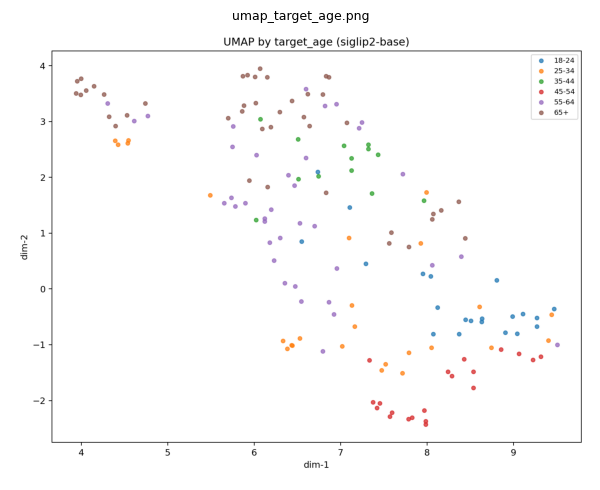

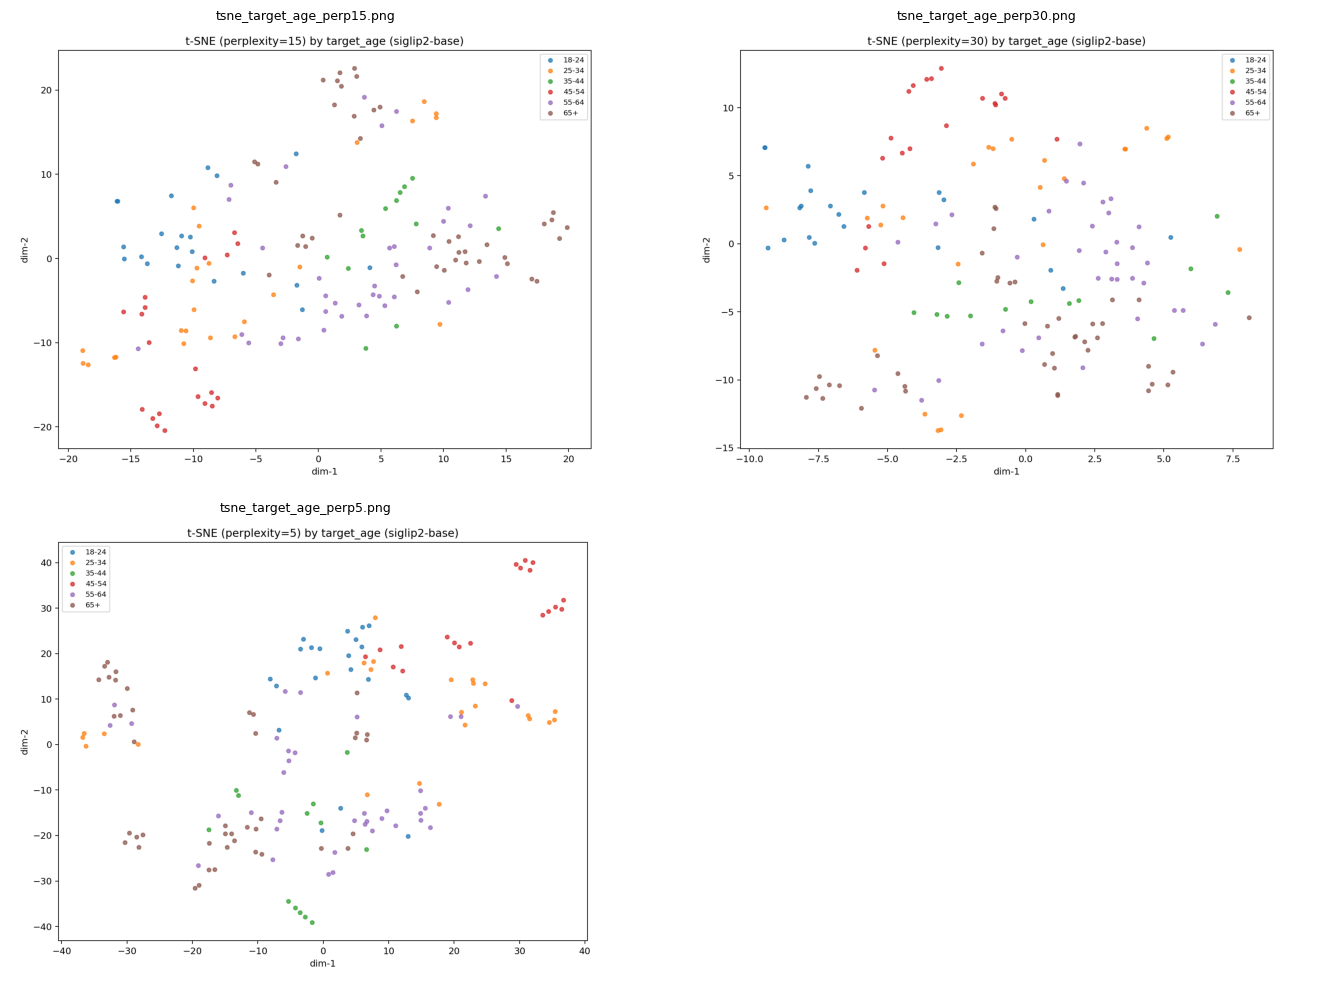

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_images(paths: list, cols: int = 2, title_prefix: str = "") -> None:
    paths = [Path(p) for p in paths if Path(p).exists()]
    if not paths:
        print("표시할 이미지가 없습니다.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 5))
    axes = [axes] if rows == 1 and cols == 1 else (
        axes.flatten() if hasattr(axes, "flatten") else [axes]
    )
    for ax, p in zip(axes, paths):
        ax.imshow(mpimg.imread(str(p)))
        ax.set_title(f"{title_prefix}{p.name}", fontsize=9)
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# UMAP
show_images([VIZ_DIR / "umap_target_age.png"], cols=1, title_prefix="")

# t-SNE (perplexity별)
tsne_files = sorted(VIZ_DIR.glob("tsne_target_age_perp*.png"))
show_images(tsne_files, cols=2)

---
## 모델 평가 점수 확인

Step 3에서 생성된 `model_scores.csv`를 DataFrame으로 출력합니다.

In [14]:
import pandas as pd

scores_path = EVAL_DIR / "model_scores.csv"
if scores_path.exists():
    df_scores = pd.read_csv(scores_path)
    display_cols = [
        "model_alias", "n_samples", "embedding_dim",
        "silhouette_umap", "knn_purity_k10_umap",
        "trustworthiness_umap", "linear_probe_macro_f1_mean",
    ]
    display(
        df_scores[display_cols]
        .style
        .background_gradient(cmap="RdYlGn", subset=display_cols[3:])
        .format({c: "{:.4f}" for c in display_cols[3:]})
        .set_caption("모델 평가 점수 (내림차순 정렬)")
    )
else:
    print(f"파일 없음: {scores_path}  →  Step 3(evaluate)를 먼저 실행하세요.")

,model_alias,n_samples,embedding_dim,silhouette_umap,knn_purity_k10_umap,trustworthiness_umap,linear_probe_macro_f1_mean
0,siglip2-base,158,768,-0.0136,0.5215,0.8581,0.3750
1,dinov2-base,158,768,-0.0705,0.4449,0.8822,0.3599


---

## 분석 결과 요약

### 모델 비교

| 지표 | SigLIP2-base | DINOv2-base | 해석 |
|---|---|---|---|
| Silhouette (UMAP) | **-0.014** | -0.071 | 둘 다 음수 → 연령대 클러스터 경계 불명확 |
| kNN Purity k10 (UMAP) | **0.522** | 0.445 | 랜덤(0.167) 대비 약 3배 → 약한 신호 존재 |
| Trustworthiness | 0.858 | **0.882** | 두 모델 모두 UMAP 시각화 신뢰 가능 |
| Linear Probe F1 | **0.375** | 0.360 | 랜덤(0.167) 대비 약 2배 → 실용적 분류는 어려운 수준 |

→ 모든 지표에서 **SigLIP2-base**가 우세하여 최종 선택 모델로 선정

---

### 핵심 발견

**1. 연령대 구분 신호는 존재하지만 약하다**

- kNN Purity(0.52)와 Linear Probe F1(0.375) 모두 랜덤 베이스라인(0.167)을 크게 상회
- 그러나 Silhouette 음수 값과 t-SNE 시각화의 색상 혼재가 보여주듯, 연령대별 클러스터가 명확하게 분리되지는 않음
- **썸네일 이미지에 연령대별 시각적 차이는 있지만, 그 차이가 임베딩 공간에서 선형적으로 분리될 만큼 뚜렷하지 않다**

**2. UMAP 시각화는 신뢰할 수 있다**

- Trustworthiness 0.86~0.88은 양호한 수준
- 시각화에서 클러스터가 보이지 않는 것은 축소 왜곡이 아니라, **원본 임베딩 자체의 특성**을 반영

**3. SigLIP2가 DINOv2보다 연령대 정보를 더 잘 포착**

- 이미지-텍스트 대조 학습으로 사전학습된 SigLIP2가 순수 이미지 자기지도 학습 모델(DINOv2)보다 연령대별 시각적 스타일 차이에 민감
- 썸네일의 **텍스트, 색감, 구도** 등 의미론적 특징을 더 잘 인코딩하는 것으로 해석

---

### 한계 및 후속 연구 방향

| 한계 | 개선 방향 |
|---|---|
| 채널당 영상 수가 적어 연령대별 샘플 불균형 존재 | 채널 및 영상 수 확대 |
| 썸네일 이미지만 사용 (단일 모달리티) | 제목 텍스트, 태그 등 텍스트 특징 결합 (멀티모달) |
| Shorts 자동 필터링만 적용 (수동 검토 없음) | `manual_review_template.csv` 기반 수동 레이블 보완 |
| 연령대 레이블이 채널 단위 (영상별 정밀 레이블 없음) | 영상별 시청자 연령 데이터 확보 (YouTube Analytics) |